In [ ]:
!pip install transformers torch pandas scikit-learn

import json
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModel, AutoTokenizer
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
import pandas as pd
from tqdm import tqdm

# Thiết lập device sử dụng GPU T4
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Đang sử dụng thiết bị: {device}")

Đang sử dụng thiết bị: cuda


Đang sử dụng thiết bị: cuda

--- BƯỚC 2: Đọc và xử lý dữ liệu ---

--- BƯỚC 3: Khởi tạo Dataset (Tăng Batch Size) ---

--- BƯỚC 4: Khởi tạo mô hình PhoBERT ABSA (Multi-Sample Dropout) ---


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base-v2
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



--- BƯỚC 5: Huấn luyện với Layer-wise Learning Rate Decay ---

Epoch 1/5


Validation: 100%|██████████| 140/140 [01:01<00:00,  2.27it/s]


...

Train Loss: 1.0974 | Train Acc: 0.9286 | Train F1: 0.8986
Val Loss:   1.1202 | Val Acc:   0.9254 | Val F1:   0.8947
-> Val F1 tăng từ 0.8657 lên 0.8947. Đang lưu mô hình...

Epoch 4/5


Validation: 100%|██████████| 140/140 [01:01<00:00,  2.28it/s]


Train Loss: 0.8900 | Train Acc: 0.9407 | Train F1: 0.9187
Val Loss:   1.0482 | Val Acc:   0.9280 | Val F1:   0.8966
-> Val F1 tăng từ 0.8947 lên 0.8966. Đang lưu mô hình...

Epoch 5/5


Validation: 100%|██████████| 140/140 [01:01<00:00,  2.27it/s]


Train Loss: 0.7840 | Train Acc: 0.9479 | Train F1: 0.9305
Val Loss:   1.0208 | Val Acc:   0.9282 | Val F1:   0.8966
-> Val F1 tăng từ 0.8966 lên 0.8966. Đang lưu mô hình...

--- BƯỚC 6: Vẽ biểu đồ và Xuất Confusion Matrix ---


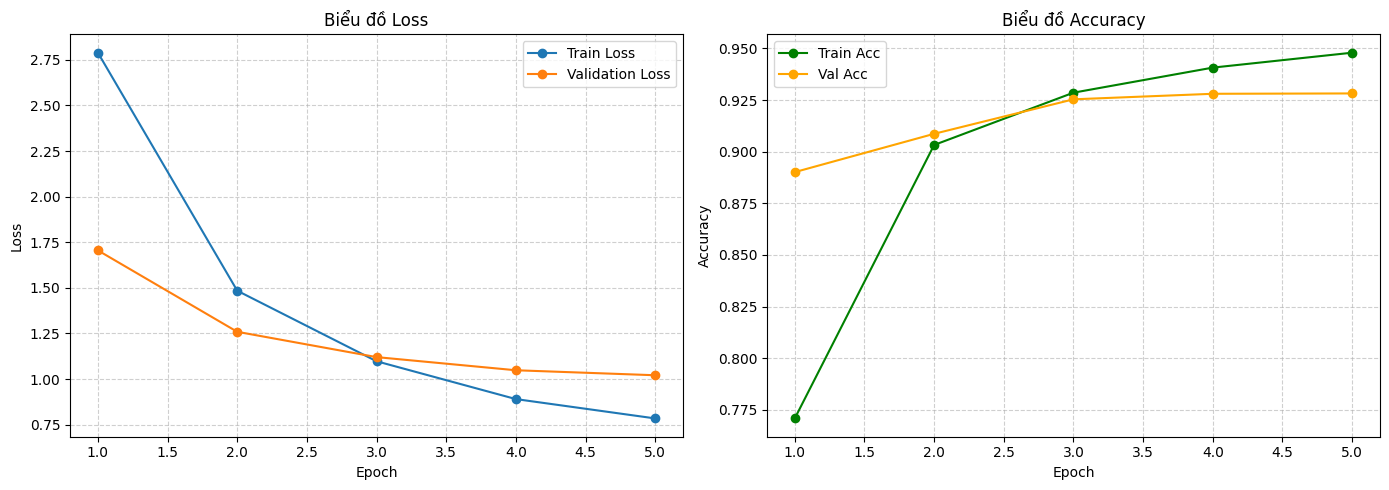

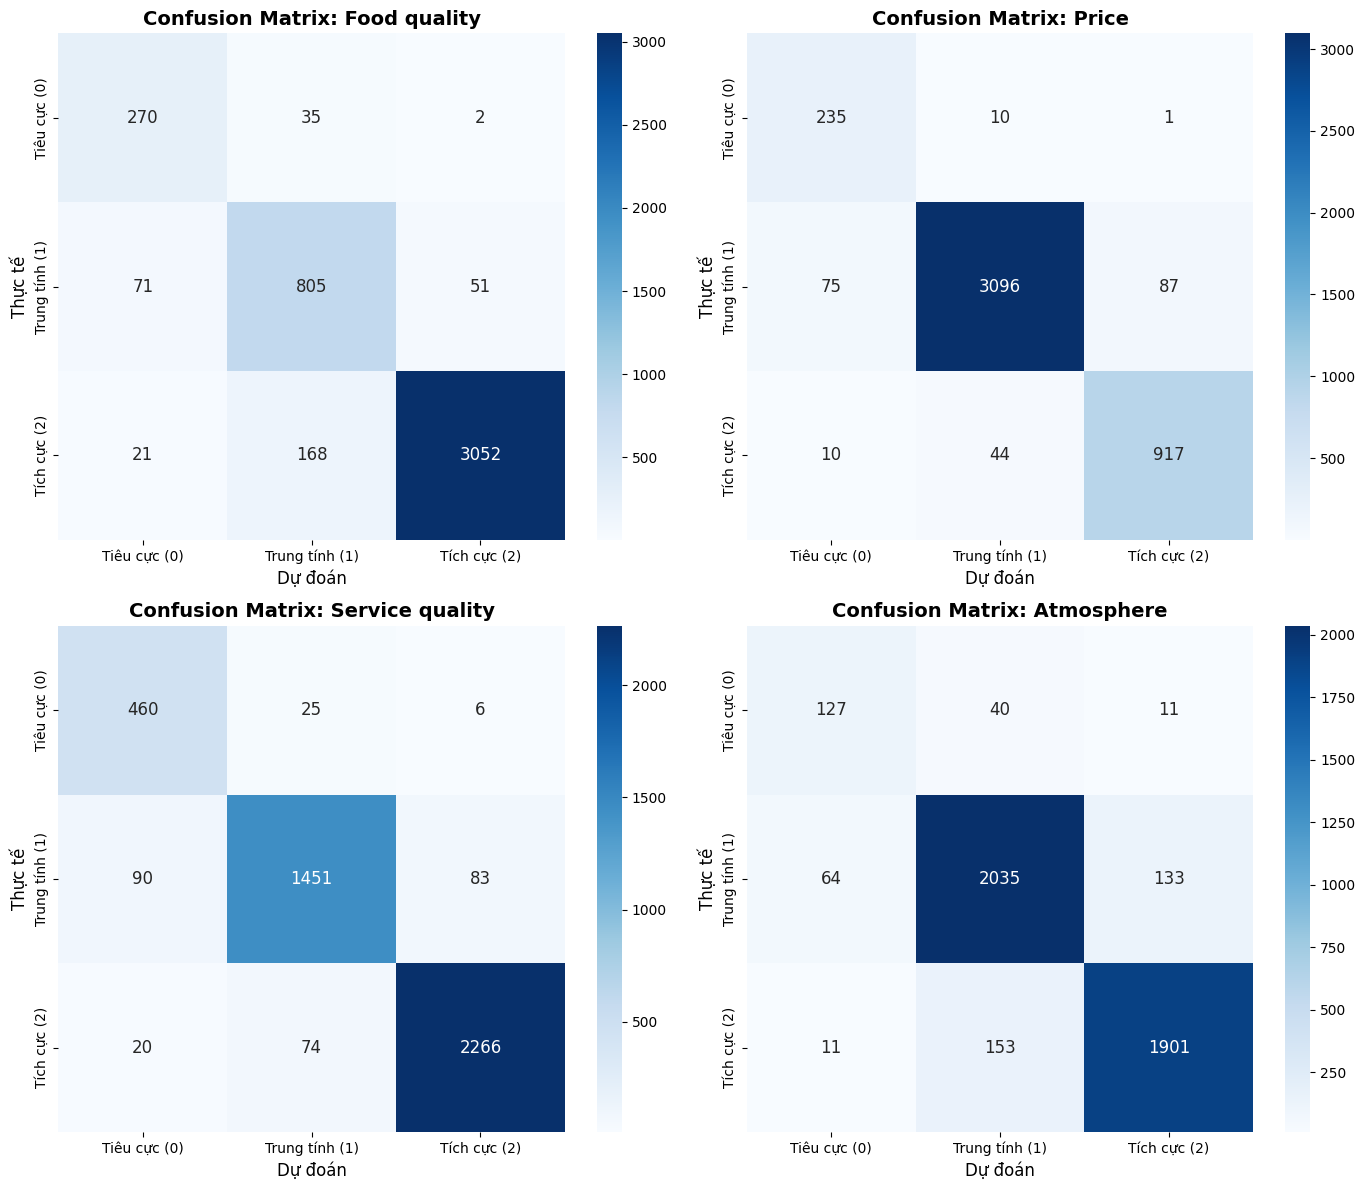


BẢNG CONFUSION MATRIX DÀNH CHO BÁO CÁO (MARKDOWN)

### 🎯 Food quality
|                        |   Dự đoán Tiêu cực (0) |   Dự đoán Trung tính (1) |   Dự đoán Tích cực (2) |
|:-----------------------|-----------------------:|-------------------------:|-----------------------:|
| Thực tế Tiêu cực (0)   |                    270 |                       35 |                      2 |
| Thực tế Trung tính (1) |                     71 |                      805 |                     51 |
| Thực tế Tích cực (2)   |                     21 |                      168 |                   3052 |

### 🎯 Price
|                        |   Dự đoán Tiêu cực (0) |   Dự đoán Trung tính (1) |   Dự đoán Tích cực (2) |
|:-----------------------|-----------------------:|-------------------------:|-----------------------:|
| Thực tế Tiêu cực (0)   |                    235 |                       10 |                      1 |
| Thực tế Trung tính (1) |                     75 |                     3096 |      

In [4]:
import json
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModel, AutoTokenizer
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from transformers import get_linear_schedule_with_warmup
from torch.amp import autocast, GradScaler
import torch.nn.functional as F
from sklearn.metrics import f1_score

# Cấu hình thiết bị
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Đang sử dụng thiết bị: {device}")

# ==========================================
# BƯỚC 2: XỬ LÝ DỮ LIỆU
# ==========================================
print("\n--- BƯỚC 2: Đọc và xử lý dữ liệu ---")
with open('labeled_results_all_v6.json', 'r', encoding='utf-8') as f:
    raw_data = json.load(f)

def map_label(value):
    if value == 0.0: return 0
    elif value == 0.5: return 1
    elif value == 1.0: return 2
    return 1

processed_data = []
for item in raw_data:
    text = item['original_data']['textTranslated']
    labels = {l['name']: map_label(l['value']) for l in item['labels']}

    processed_data.append({
        'text': text,
        'Food quality': labels.get('Food quality', 1),
        'Price': labels.get('Price', 1),
        'Service quality': labels.get('Service quality', 1),
        'Atmosphere': labels.get('Atmosphere', 1)
    })

df = pd.DataFrame(processed_data)
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

# ==========================================
# BƯỚC 3: DATASET & DATALOADER
# ==========================================
print("\n--- BƯỚC 3: Khởi tạo Dataset (Tăng Batch Size) ---")
tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base-v2")

class RestaurantReviewDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=256):
        self.df = df
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.texts = df['text'].values
        self.aspect_labels = df[['Food quality', 'Price', 'Service quality', 'Atmosphere']].values

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        text = str(self.texts[index])
        labels = self.aspect_labels[index]

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(labels, dtype=torch.long)
        }

# TĂNG BATCH SIZE LÊN 32 ĐỂ TẬN DỤNG TỐI ĐA GPU T4
BATCH_SIZE = 32

train_dataset = RestaurantReviewDataset(train_df, tokenizer)
val_dataset = RestaurantReviewDataset(val_df, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

# ==========================================
# BƯỚC 4: KHỞI TẠO MÔ HÌNH
# ==========================================
print("\n--- BƯỚC 4: Khởi tạo mô hình PhoBERT ABSA (Multi-Sample Dropout) ---")
class PhoBertABSA(nn.Module):
    def __init__(self, n_classes=3, n_aspects=4):
        super(PhoBertABSA, self).__init__()
        self.phobert = AutoModel.from_pretrained("vinai/phobert-base-v2")

        # Tạo 5 lớp dropout với tỷ lệ 0.1
        self.dropouts = nn.ModuleList([nn.Dropout(p=0.1) for _ in range(5)])

        self.classifiers = nn.ModuleList([
            nn.Linear(self.phobert.config.hidden_size, n_classes) for _ in range(n_aspects)
        ])

    def forward(self, input_ids, attention_mask):
        outputs = self.phobert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.pooler_output

        logits = []
        for classifier in self.classifiers:
            # Cho pooled_output đi qua 5 dropout khác nhau -> qua classifier -> tính trung bình cộng
            stacked_logits = torch.stack([classifier(drop(pooled_output)) for drop in self.dropouts], dim=0)
            aspect_logits = torch.mean(stacked_logits, dim=0)
            logits.append(aspect_logits)

        return logits

model = PhoBertABSA().to(device)

# ==========================================
# BƯỚC 5 (NÂNG CẤP): HUẤN LUYỆN KÈM SCHEDULER & DAMPENED WEIGHTS
# ==========================================
print("\n--- BƯỚC 5: Huấn luyện với Layer-wise Learning Rate Decay ---")
EPOCHS = 5
MAX_LR = 3e-5 # Learning rate lớn nhất (dành cho lớp Classifier ở trên cùng)
LLRD_DECAY = 0.9 # Tỷ lệ giảm dần LR cho các lớp bên dưới
WEIGHT_DECAY = 0.01

class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0, reduction='mean', label_smoothing=0.0):
        super(FocalLoss, self).__init__()
        self.weight = weight
        self.gamma = gamma
        self.reduction = reduction
        self.label_smoothing = label_smoothing

    def forward(self, inputs, targets):
        # Tính Cross Entropy truyền thống (có hỗ trợ label smoothing)
        ce_loss = F.cross_entropy(
            inputs, targets, weight=self.weight,
            reduction='none', label_smoothing=self.label_smoothing
        )

        # Tính p_t (xác suất dự đoán cho class đúng)
        pt = torch.exp(-ce_loss)

        # Công thức Focal Loss
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss
# 1. HÀM TẠO NHÓM THAM SỐ VỚI LLRD
def get_optimizer_grouped_parameters(model, max_lr, weight_decay, llrd_decay):
    opt_parameters = []

    # Tham số không áp dụng weight decay (bias, LayerNorm)
    no_decay = ["bias", "LayerNorm.weight"]

    # Classifier / Head (Lớp trên cùng) - Nhận Max LR
    head_params = {"params": [p for n, p in model.classifiers.named_parameters()], "lr": max_lr}
    opt_parameters.append(head_params)

    # 12 Lớp Encoder của PhoBERT - Giảm dần LR từ trên xuống dưới
    for layer_idx in range(11, -1, -1):
        # Tính LR cho layer hiện tại
        layer_lr = max_lr * (llrd_decay ** (12 - layer_idx))

        layer_params = [
            p for n, p in model.phobert.encoder.layer[layer_idx].named_parameters() if not any(nd in n for nd in no_decay)
        ]
        layer_params_no_decay = [
            p for n, p in model.phobert.encoder.layer[layer_idx].named_parameters() if any(nd in n for nd in no_decay)
        ]

        if layer_params:
            opt_parameters.append({"params": layer_params, "weight_decay": weight_decay, "lr": layer_lr})
        if layer_params_no_decay:
            opt_parameters.append({"params": layer_params_no_decay, "weight_decay": 0.0, "lr": layer_lr})

    # Lớp Embeddings (Lớp dưới cùng) - Nhận LR nhỏ nhất
    embed_lr = max_lr * (llrd_decay ** 13)
    embed_params = [p for n, p in model.phobert.embeddings.named_parameters() if not any(nd in n for nd in no_decay)]
    embed_params_no_decay = [p for n, p in model.phobert.embeddings.named_parameters() if any(nd in n for nd in no_decay)]

    if embed_params:
        opt_parameters.append({"params": embed_params, "weight_decay": weight_decay, "lr": embed_lr})
    if embed_params_no_decay:
        opt_parameters.append({"params": embed_params_no_decay, "weight_decay": 0.0, "lr": embed_lr})

    return opt_parameters

# 2. KHỞI TẠO OPTIMIZER VỚI CÁC NHÓM PARAMETERS ĐÃ CHIA LLRD
grouped_params = get_optimizer_grouped_parameters(model, MAX_LR, WEIGHT_DECAY, LLRD_DECAY)
optimizer = AdamW(grouped_params)
scaler = GradScaler()

# 3. HÀM TÍNH TRỌNG SỐ (Vẫn giữ Dampened + Label Smoothing)
def get_dampened_class_weights(labels_array):
    classes = np.unique(labels_array)
    weights = compute_class_weight(class_weight='balanced', classes=classes, y=labels_array)
    dampened_weights = np.sqrt(weights)
    return torch.tensor(dampened_weights, dtype=torch.float).to(device)
def get_safe_class_weights(labels_array, max_weight=4.0):
    classes = np.unique(labels_array)
    weights = compute_class_weight(class_weight='balanced', classes=classes, y=labels_array)

    # Clip (Giới hạn) trọng số để tránh bùng nổ gradient
    # Trọng số không được nhỏ hơn 0.5 và không lớn hơn max_weight
    weights = np.clip(weights, a_min=0.5, a_max=max_weight)

    return torch.tensor(weights, dtype=torch.float).to(device)
aspect_columns = ['Food quality', 'Price', 'Service quality', 'Atmosphere']

# THAY THẾ nn.CrossEntropyLoss bằng FocalLoss
loss_fns = [
    nn.CrossEntropyLoss(
        weight=get_safe_class_weights(train_df[col].values)
    )
    for col in aspect_columns
]

# 4. KHỞI TẠO SCHEDULER
total_steps = len(train_loader) * EPOCHS
num_warmup_steps = int(total_steps * 0.1)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=total_steps
)

def train_epoch(model, data_loader, loss_fns, optimizer, scheduler, device):
    model.train()
    total_loss, total_correct, total_samples = 0, 0, 0
    all_preds = []
    all_targets = []

    for batch in tqdm(data_loader, desc="Training"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()

        # ĐÃ BỎ WITH AUTOCAST ĐỂ ĐẢM BẢO AN TOÀN TOÁN HỌC (DÙNG FLOAT32)
        logits = model(input_ids, attention_mask)
        loss = 0
        for i in range(4):
            loss += loss_fns[i](logits[i], labels[:, i])

            preds = torch.argmax(logits[i], dim=1)
            total_correct += (preds == labels[:, i]).sum().item()
            total_samples += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(labels[:, i].cpu().numpy())

        # BẪY LỖI NAN
        if torch.isnan(loss):
            print("\n[CẢNH BÁO] Loss = nan phát hiện giữa chừng! Hãy dừng chương trình.")
            return float('nan'), 0, 0

        # Backpropagation chuẩn (không dùng scaler do đã tắt autocast)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

    from sklearn.metrics import f1_score
    macro_f1 = f1_score(all_targets, all_preds, average='macro', zero_division=0)
    return total_loss / len(data_loader), total_correct / total_samples, macro_f1

def val_epoch(model, data_loader, loss_fns, device):
    model.eval()
    total_loss, total_correct, total_samples = 0, 0, 0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for batch in tqdm(data_loader, desc="Validation"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            logits = model(input_ids, attention_mask)

            loss = 0
            for i in range(4):
                loss += loss_fns[i](logits[i], labels[:, i])
                preds = torch.argmax(logits[i], dim=1)
                total_correct += (preds == labels[:, i]).sum().item()
                total_samples += labels.size(0)

                all_preds.extend(preds.cpu().numpy())
                all_targets.extend(labels[:, i].cpu().numpy())

            total_loss += loss.item()

    macro_f1 = f1_score(all_targets, all_preds, average='macro')
    return total_loss / len(data_loader), total_correct / total_samples, macro_f1

history = {'train_loss': [], 'train_acc': [], 'train_f1': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}
best_val_f1 = 0.0 # Đổi sang track theo F1 thay vì Loss

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")

    train_loss, train_acc, train_f1 = train_epoch(model, train_loader, loss_fns, optimizer, scheduler, device)
    val_loss, val_acc, val_f1 = val_epoch(model, val_loader, loss_fns, device)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Train F1: {train_f1:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f} | Val F1:   {val_f1:.4f}")

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['train_f1'].append(train_f1)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    # LƯU BEST MODEL DỰA TRÊN MACRO F1
    if val_f1 > best_val_f1:
        print(f"-> Val F1 tăng từ {best_val_f1:.4f} lên {val_f1:.4f}. Đang lưu mô hình...")
        best_val_f1 = val_f1
        torch.save(model.state_dict(), 'best_phobert_absa.pth')

# ==========================================
# BƯỚC 6: ĐÁNH GIÁ & XUẤT CONFUSION MATRIX
# ==========================================
print("\n--- BƯỚC 6: Vẽ biểu đồ và Xuất Confusion Matrix ---")

# Vẽ biểu đồ Loss & Accuracy
epochs_range = range(1, EPOCHS + 1)
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_loss'], label='Train Loss', marker='o')
plt.plot(epochs_range, history['val_loss'], label='Validation Loss', marker='o')
plt.title('Biểu đồ Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['train_acc'], label='Train Acc', marker='o', color='green')
plt.plot(epochs_range, history['val_acc'], label='Val Acc', marker='o', color='orange')
plt.title('Biểu đồ Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# LOAD LẠI BEST MODEL ĐỂ ĐÁNH GIÁ MA TRẬN NHẦM LẪN
model.load_state_dict(torch.load('best_phobert_absa.pth'))
model.eval()

all_preds = {0: [], 1: [], 2: [], 3: []}
all_labels = {0: [], 1: [], 2: [], 3: []}

with torch.no_grad():
    for batch in val_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        logits = model(input_ids, attention_mask)

        for i in range(4):
            preds = torch.argmax(logits[i], dim=1).cpu().numpy()
            all_preds[i].extend(preds)
            all_labels[i].extend(labels[:, i].cpu().numpy())

# Vẽ hình Confusion Matrix
class_names = ['Tiêu cực (0)', 'Trung tính (1)', 'Tích cực (2)']
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for i in range(4):
    cm = confusion_matrix(all_labels[i], all_preds[i], labels=[0, 1, 2])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=class_names, yticklabels=class_names, annot_kws={"size": 12})
    axes[i].set_title(f'Confusion Matrix: {aspect_columns[i]}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Dự đoán', fontsize=12)
    axes[i].set_ylabel('Thực tế', fontsize=12)

plt.tight_layout()
plt.show()

# In bảng Markdown để copy vào báo cáo
print("\n" + "="*50)
print("BẢNG CONFUSION MATRIX DÀNH CHO BÁO CÁO (MARKDOWN)")
print("="*50)

for i in range(4):
    cm = confusion_matrix(all_labels[i], all_preds[i], labels=[0, 1, 2])
    df_cm = pd.DataFrame(
        cm,
        index=[f'Thực tế {c}' for c in class_names],
        columns=[f'Dự đoán {c}' for c in class_names]
    )
    print(f"\n### 🎯 {aspect_columns[i]}")
    print(df_cm.to_markdown())